
Single Image Prediction


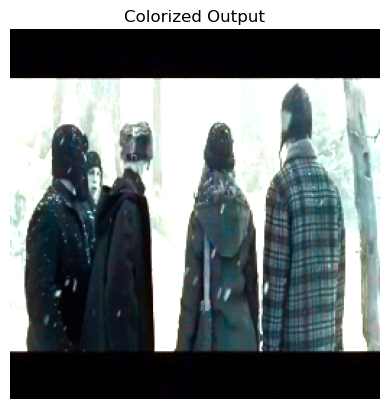

Saved single image prediction to: results/run_20250503_095635/single_prediction.png

📊 Batch Validation with PSNR & SSIM

 Validation Metrics:
psnr: 7.1976
ssim: 0.2327
psnr_std: 1.3427
ssim_std: 0.0267
Saved metrics to: results/run_20250503_095635/metrics.json
Saved prediction 1 to: results/run_20250503_095635/prediction_1.png
Saved prediction 2 to: results/run_20250503_095635/prediction_2.png
Saved prediction 3 to: results/run_20250503_095635/prediction_3.png
Saved prediction 4 to: results/run_20250503_095635/prediction_4.png
Saved prediction 5 to: results/run_20250503_095635/prediction_5.png
Saved prediction 6 to: results/run_20250503_095635/prediction_6.png
Saved prediction 7 to: results/run_20250503_095635/prediction_7.png
Saved prediction 8 to: results/run_20250503_095635/prediction_8.png


In [1]:
import sys
import os
import warnings
import json
from datetime import datetime

warnings.filterwarnings('ignore')

# === Fix path for relative imports ===
sys.path.append(os.path.abspath('src'))


import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob

from prediction import Predictor
from validation import Validator

# === Parameters ===
MODEL_PATH = 'models/final_generator.pth'
SINGLE_IMAGE_PATH = 'data/images/frame1.jpg'
VAL_DIR_GLOB = 'data/validation/**/*.jpg'
RESOLUTION = (256, 256)
NUM_VALIDATION_IMAGES = 8
RESULTS_DIR = 'results'
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_DIR = os.path.join(RESULTS_DIR, f"run_{TIMESTAMP}")

# === Create results directory ===
os.makedirs(RUN_DIR, exist_ok=True)

# === Step 1: Predict a Single Image ===
if os.path.exists(SINGLE_IMAGE_PATH):
    print("\nSingle Image Prediction")
    img = Image.open(SINGLE_IMAGE_PATH).convert('L').resize(RESOLUTION)
    input_data = np.array(img)

    predictor = Predictor(model_path=MODEL_PATH)
    predicted_rgb = predictor.predict(input_data)

    output_img_path = os.path.join(RUN_DIR, 'single_prediction.png')
    Image.fromarray((predicted_rgb[0] * 255).astype(np.uint8)).save(output_img_path)

    plt.imshow(predicted_rgb[0])
    plt.title("Colorized Output")
    plt.axis("off")
    plt.show()
    print(f"Saved single image prediction to: {output_img_path}")
else:
    print(f"\nSingle image not found at: {SINGLE_IMAGE_PATH}")

# === Step 2: Batch Validation with Ground Truth ===
print("\n📊 Batch Validation with PSNR & SSIM")
val_paths = glob(VAL_DIR_GLOB, recursive=True)[:NUM_VALIDATION_IMAGES]

if not val_paths:
    print("No validation images found. Please check the path:", VAL_DIR_GLOB)
    sys.exit(1)

ground_truth_batch = np.stack([
    np.array(Image.open(p).convert('RGB').resize(RESOLUTION)) for p in val_paths
])

validator = Validator(model_path=MODEL_PATH)
results = validator.validate(validation_data=ground_truth_batch, ground_truth=ground_truth_batch)

# === Step 3: Print & Save Evaluation Metrics ===
metrics_path = os.path.join(RUN_DIR, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(results['metrics'], f, indent=2)
print("\n Validation Metrics:")
for key, val in results['metrics'].items():
    print(f"{key}: {val:.4f}")
print(f"Saved metrics to: {metrics_path}")

# === Step 4: Save All Batch Predictions ===
for i, rgb_img in enumerate(results['predictions']):
    save_path = os.path.join(RUN_DIR, f'prediction_{i+1}.png')
    Image.fromarray((rgb_img * 255).astype(np.uint8)).save(save_path)
    print(f"Saved prediction {i+1} to: {save_path}")
